# AI Crypto Hedge Fund

This notebook is the deliverable; reusable logic lives in `src/fund/` and is imported here.

**Rules enforced throughout** (see `CLAUDE.md`): reproducible (uv env, pinned versions, fixed seeds, local `data/*.csv` only, no network calls here); no look-ahead bias (positions `.shift(1)`, targets `.shift(-1)`, fit on train only); crypto annualization = 365; transaction costs deducted; benchmarked vs buy-and-hold BTC and equal-weight.

**Build order:** baseline → single-coin AI → static portfolio → dynamic rebalancing → 100+ pairs.

## 1. Setup & Data Loading

Imports, global seed, and loading the local OHLCV CSVs (produced offline by `scripts/download_data.py`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fund import ANNUALIZATION
from fund import data, features, metrics, backtest, agents, portfolio

SEED = 42
np.random.seed(SEED)

assert ANNUALIZATION == 365  # crypto, not 252

In [2]:
# Load BTC daily OHLCV from local CSV (no network here) and compute returns.
btc = data.load_coin("BTC")
close = btc["close"]
btc_returns = close.pct_change()

print(f"BTC: {len(btc)} rows, {btc.index.min().date()} -> {btc.index.max().date()}")
btc.head()

BTC: 550 rows, 2024-12-20 -> 2026-06-22


,open,high,low,close,volume
timestamp,,,,,
2024-12-20,97461.86,98233.00,92232.54,97805.44,62884.13570
2024-12-21,97805.44,99540.61,96398.39,97291.99,23483.54143
2024-12-22,97292.00,97448.08,94250.35,95186.27,19353.83036
2024-12-23,95186.28,96538.92,92520.00,94881.47,32810.76703
2024-12-24,94881.47,99487.99,93569.02,98663.58,23674.22488


Loaded ~18 months of daily BTC/USDT. `btc_returns` (simple daily returns) is the building block reused by every later level.

## 2. Baseline

**Level 1 — BTC 7/21 moving-average crossover (long/flat).** A hand-coded rule: hold BTC when the fast MA is above the slow MA, otherwise sit in cash. Backtested net of 10 bps per trade and benchmarked against buy-and-hold BTC.

In [3]:
# 7/21 moving-average crossover on BTC (long/flat).
ma_fast = close.rolling(7).mean()
ma_slow = close.rolling(21).mean()

# Position decided at end of day t from MAs up to t: long (1) when fast>slow, else flat (0).
# Flip to long/short with: position = np.sign(ma_fast - ma_slow)
position = (ma_fast > ma_slow).astype(float)

# Net-of-cost returns: backtest applies .shift(1) (trade next bar) and charges
# 10 bps (cost=0.001) on turnover |Δposition|. Benchmark = buy-and-hold BTC.
strat = backtest.backtest_positions(position, btc_returns, cost=0.001)
bnh = backtest.benchmark_buy_and_hold_btc(btc_returns)

In [4]:
# Full metrics suite, strategy vs benchmark.
table = pd.DataFrame({
    "MA 7/21": metrics.summary(strat, position),
    "Buy & Hold": metrics.summary(bnh),
})
table.round(4)

,MA 7/21,Buy & Hold
roi,0.0067,-0.3406
cagr,0.0045,-0.2414
ann_vol,0.2377,0.4424
sharpe,0.1372,-0.4040
sortino,0.1998,-0.5641
calmar,0.0134,-0.4719
max_drawdown,-0.3326,-0.5116
var_95,0.0207,0.0360
cvar_95,0.0310,0.0524
win_rate,0.4904,0.4873


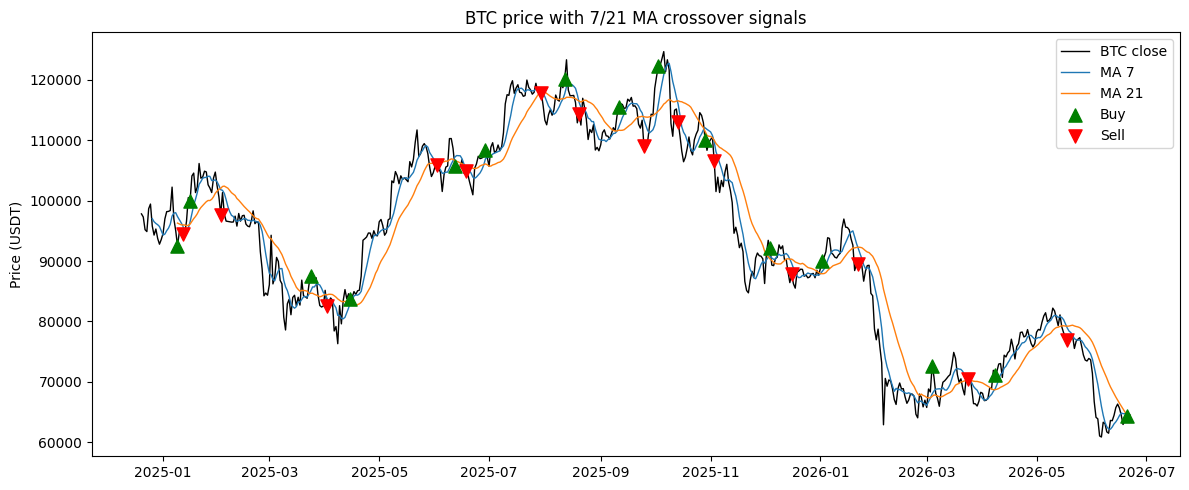

In [5]:
# Plot 1: price with MAs and crossover entry/exit markers.
entries = position.diff() == 1   # flat -> long (buy)
exits = position.diff() == -1    # long -> flat (sell)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close, label="BTC close", color="black", lw=1)
ax.plot(ma_fast.index, ma_fast, label="MA 7", color="tab:blue", lw=1)
ax.plot(ma_slow.index, ma_slow, label="MA 21", color="tab:orange", lw=1)
ax.scatter(close.index[entries], close[entries], marker="^", color="green", s=90, label="Buy", zorder=5)
ax.scatter(close.index[exits], close[exits], marker="v", color="red", s=90, label="Sell", zorder=5)
ax.set_title("BTC price with 7/21 MA crossover signals")
ax.set_ylabel("Price (USDT)")
ax.legend()
fig.tight_layout()
plt.show()

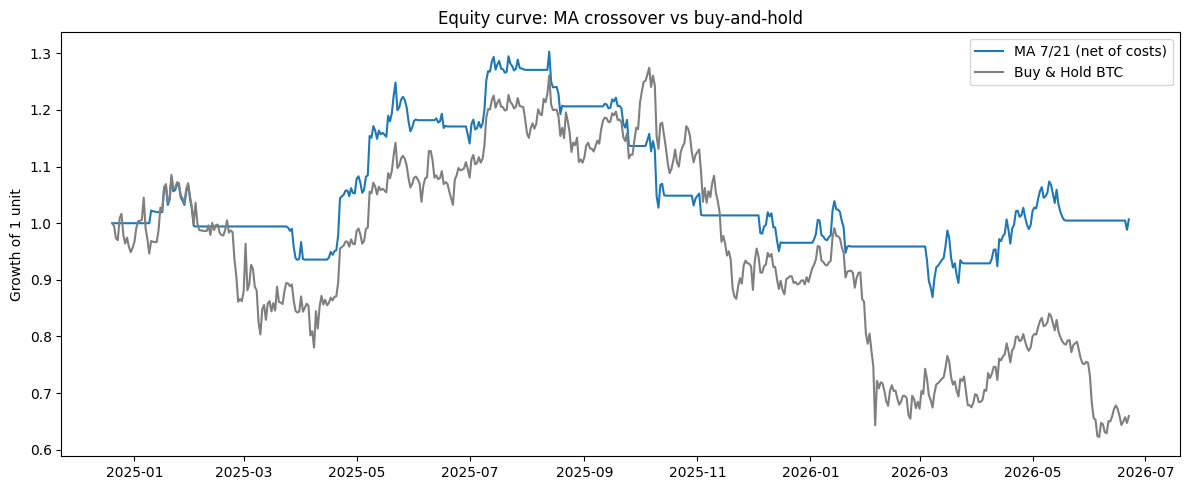

In [6]:
# Plot 2: equity curve vs buy-and-hold.
strat_equity = (1 + strat.fillna(0)).cumprod()
bnh_equity = (1 + bnh.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strat_equity.index, strat_equity, label="MA 7/21 (net of costs)", color="tab:blue")
ax.plot(bnh_equity.index, bnh_equity, label="Buy & Hold BTC", color="tab:gray")
ax.set_title("Equity curve: MA crossover vs buy-and-hold")
ax.set_ylabel("Growth of 1 unit")
ax.legend()
fig.tight_layout()
plt.show()

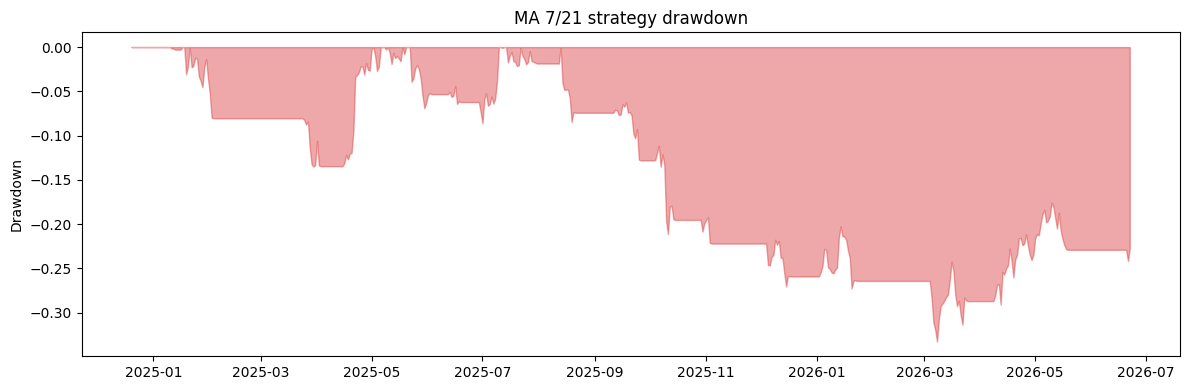

In [7]:
# Plot 3: strategy drawdown.
drawdown = strat_equity / strat_equity.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(drawdown.index, drawdown, 0, color="tab:red", alpha=0.4)
ax.set_title("MA 7/21 strategy drawdown")
ax.set_ylabel("Drawdown")
fig.tight_layout()
plt.show()

**Reading the results.** The 7/21 crossover is a trend-follower: it goes flat during downtrends, which usually cuts the worst drawdowns (smaller `max_drawdown`/`var_95`) at the cost of missing some sharp rebounds. Whether it beats buy-and-hold on `sharpe`/`calmar` depends on the regime in this ~18-month window; the metrics table makes the trade-off explicit, and `turnover`/`n_trades` show the (small) cost footprint of a slow crossover.

**How this evolves into an AI agent.** The crossover is a single hand-coded rule with two fixed parameters. In Level 2 we replace the rule with *trained/forecast* signals: engineer features (momentum, volatility, RSI — see `fund.features`), define the target as next-day direction via `.shift(-1)`, fit models on the **train split only**, and turn their outputs into positions wrapped in the `fund.agents.Agent` interface (Input → Logic → Output → Risk constraint) — reusing this exact `backtest` + `metrics` plumbing so the baseline is the apples-to-apples yardstick.

## 3. Single-Coin AI

Three agents on BTC, all **fit on the train split only** and compared out-of-sample on the test split against the Level 1 baseline:

1. **Econometric** — ARIMA(1,0,1) for next-day return direction (walk-forward) + GARCH(1,1) for a volatility regime.
2. **ML** — `RandomForestClassifier` and `LogisticRegression` on the feature set, `StandardScaler` fit on train only, trade when `P(up) > 0.55`.
3. **Deterministic AI** — combines technical + ML probability + volatility regime + drawdown into discrete actions {buy, hold, reduce, exit}.

Finally a **permutation/shuffle test** asks whether each strategy's *timing* is better than random.

In [8]:
import warnings
warnings.filterwarnings("ignore")  # silence statsmodels frequency/convergence notes

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Features + next-day-up target on BTC, then a chronological 70/30 split.
feat = features.make_features(btc)
df = feat.copy()
df["target"] = features.make_target(close)
df["ret"] = close.pct_change()
df["close"] = close
df = df.dropna()

train, test = data.train_test_split(df, train_frac=0.7)
X_train, y_train = train[features.FEATURE_COLUMNS], train["target"]
X_test = test[features.FEATURE_COLUMNS]
ret_test = test["ret"]

print(f"train {len(train)} rows ({train.index.min().date()} -> {train.index.max().date()})")
print(f"test  {len(test)} rows ({test.index.min().date()} -> {test.index.max().date()})")

train 371 rows (2025-01-09 -> 2026-01-14)
test  159 rows (2026-01-15 -> 2026-06-22)


In [9]:
# Benchmarks restricted to the test window (apples-to-apples with the AI agents).
bnh_test = backtest.benchmark_buy_and_hold_btc(ret_test)

# Level 1 baseline: 7/21 crossover (MAs use full history up to each day, no look-
# ahead), evaluated on the test slice via the same backtest plumbing.
position_base = (close.rolling(7).mean() > close.rolling(21).mean()).astype(float)
position_base_test = position_base.loc[ret_test.index]
base_test = backtest.backtest_positions(position_base_test, ret_test, cost=0.001)

In [10]:
# (a) Econometric agent: ARIMA direction + GARCH volatility regime.
econ = agents.EconometricAgent().fit(train["ret"])
pos_econ = econ.generate(ret_test)
ret_econ = backtest.backtest_positions(pos_econ, ret_test, cost=0.001)
print("risk constraint:", econ.risk_constraint)
print("high-vol days on test:", int(econ.high_vol_.sum()), "/", len(econ.high_vol_))

/Users/timothymaximov/Projects/my-project/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timothymaximov/Projects/my-project/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timothymaximov/Projects/my-project/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


risk constraint: long-only; flat on non-positive return forecast; halve exposure in high-vol regime
high-vol days on test: 87 / 159


In [11]:
# (b) ML agents: RandomForest and LogisticRegression (scaler fit on train only).
ml_rf = agents.MLAgent(RandomForestClassifier(n_estimators=300, random_state=SEED)).fit(X_train, y_train)
pos_rf = ml_rf.generate(X_test)
ret_rf = backtest.backtest_positions(pos_rf, ret_test, cost=0.001)

ml_lr = agents.MLAgent(LogisticRegression(max_iter=1000)).fit(X_train, y_train)
pos_lr = ml_lr.generate(X_test)
ret_lr = backtest.backtest_positions(pos_lr, ret_test, cost=0.001)

print("RF days long:", int(pos_rf.sum()), "| LogReg days long:", int(pos_lr.sum()))

RF days long: 112 | LogReg days long: 115


In [12]:
# (c) Deterministic AI agent: technical + ML prob + vol regime + drawdown.
det = agents.DeterministicAIAgent()
pos_det = det.generate(test[features.FEATURE_COLUMNS], ml_rf.proba_, econ.high_vol_, test["close"])
ret_det = backtest.backtest_positions(pos_det, ret_test, cost=0.001)
print("action mix:", det.actions_.value_counts().to_dict())

action mix: {'exit': 115, 'hold': 18, 'reduce': 17, 'buy': 9}


In [13]:
# Combined comparison (test window), all six approaches in one table.
comparison = pd.DataFrame({
    "Buy & Hold": metrics.summary(bnh_test),
    "MA 7/21 (L1)": metrics.summary(base_test, position_base_test),
    "Econometric": metrics.summary(ret_econ, pos_econ),
    "ML-RF": metrics.summary(ret_rf, pos_rf),
    "ML-LogReg": metrics.summary(ret_lr, pos_lr),
    "Deterministic AI": metrics.summary(ret_det, pos_det),
})
comparison.round(4)

,Buy & Hold,MA 7/21 (L1),Econometric,ML-RF,ML-LogReg,Deterministic AI
roi,-0.3348,-0.0184,-0.2240,-0.3714,-0.1356,-0.1569
cagr,-0.6077,-0.0418,-0.4414,-0.6555,-0.2843,-0.3242
ann_vol,0.5075,0.2429,0.2706,0.4372,0.3892,0.1246
sharpe,-1.5872,-0.0552,-2.0142,-2.2112,-0.6654,-3.0813
sortino,-2.1173,-0.0800,-2.4865,-2.7110,-0.9166,-3.5313
calmar,-1.6733,-0.2745,-1.8895,-1.6631,-1.2240,-2.0659
max_drawdown,-0.3632,-0.1521,-0.2336,-0.3941,-0.2323,-0.1569
var_95,0.0392,0.0195,0.0228,0.0379,0.0372,0.0139
cvar_95,0.0620,0.0312,0.0416,0.0615,0.0496,0.0219
win_rate,0.4528,0.5000,0.3120,0.3453,0.4167,0.3333


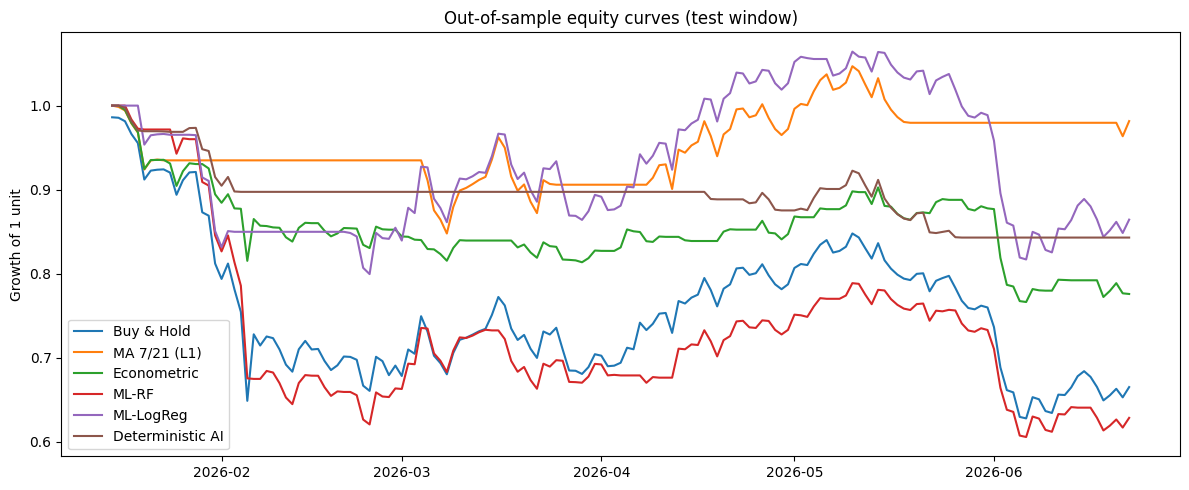

In [14]:
# Equity curves of every approach over the test window.
curves = {
    "Buy & Hold": bnh_test, "MA 7/21 (L1)": base_test, "Econometric": ret_econ,
    "ML-RF": ret_rf, "ML-LogReg": ret_lr, "Deterministic AI": ret_det,
}
fig, ax = plt.subplots(figsize=(12, 5))
for name, r in curves.items():
    ax.plot((1 + r.fillna(0)).cumprod(), label=name)
ax.set_title("Out-of-sample equity curves (test window)")
ax.set_ylabel("Growth of 1 unit")
ax.legend()
fig.tight_layout()
plt.show()

In [15]:
# Permutation/shuffle significance: is each strategy's TIMING better than random?
# We shuffle the position order 1000x, keep BTC's real return path, and recompute
# Sharpe; p = share of random-timing runs that match or beat the real strategy.
strategies = {
    "MA 7/21 (L1)": position_base_test,
    "Econometric": pos_econ,
    "ML-RF": pos_rf,
    "ML-LogReg": pos_lr,
    "Deterministic AI": pos_det,
}
rows = {}
for name, pos in strategies.items():
    sharpe_obs, p_val, _ = metrics.permutation_test(pos, ret_test, cost=0.001, n=1000, seed=SEED)
    rows[name] = {"sharpe": sharpe_obs, "perm_p_value": p_val}
pd.DataFrame(rows).T.round(4)

,sharpe,perm_p_value
MA 7/21 (L1),-0.0552,0.114
Econometric,-2.0142,0.644
ML-RF,-2.2112,0.758
ML-LogReg,-0.6654,0.111
Deterministic AI,-3.0813,0.888


**Reading the results.** All numbers are strictly out-of-sample: features use data up to day *t*, the target is next-day direction (`.shift(-1)`), models and the scaler are fit on the train slice only, and positions are applied with `.shift(1)` net of 10 bps. The combined table puts the three AI agents next to buy-and-hold and the Level 1 crossover on the identical test window.

**On significance.** A low `perm_p_value` (say < 0.05) means the strategy's *timing* beat random reshuffles of the same positions — evidence of genuine skill rather than luck. High p-values (common for daily crypto direction, where the signal-to-noise is brutal) are the honest result: a single coin over ~18 months gives little statistical edge, which is exactly why later levels diversify across a portfolio of coins.

**Next.** Level 3 reuses these agents per-coin and combines their signals into a static multi-coin portfolio, benchmarked against equal-weight.

## 4. Static Portfolio

Diversify across the 7 coins with **static** weights. Four allocations, all estimated on train and held over the test window: equal-weight, minimum-variance, maximum-Sharpe (mean-variance optimization via `scipy.optimize.minimize`), and an agent-based allocation (per-coin RandomForest conviction). Long-only, weights sum to 1, **max 40% per coin**.

In [16]:
# Universe of 7 coins; daily returns; chronological 70/30 split.
COINS = ["BTC", "ETH", "BNB", "SOL", "XRP", "ADA", "DOGE"]
universe = data.load_universe(COINS)
asset_returns = universe.pct_change().dropna()
train_r, test_r = data.train_test_split(asset_returns, train_frac=0.7)
print(f"universe {universe.shape[0]} days x {universe.shape[1]} coins")
print(f"test window {test_r.index.min().date()} -> {test_r.index.max().date()} ({len(test_r)} days)")

universe 550 days x 7 coins
test window 2026-01-09 -> 2026-06-22 (165 days)


In [17]:
# Equal-weight, min-variance, max-Sharpe (mean-variance, estimated on train).
w_equal = pd.Series(1 / len(COINS), index=COINS)
w_minvar = portfolio.min_variance_weights(train_r)
w_maxsharpe = portfolio.max_sharpe_weights(train_r)

# Agent-based: per-coin RandomForest conviction (mean train P(up)), capped at 40%.
conviction = {}
for coin in COINS:
    ohlcv = data.load_coin(coin)
    cdf = features.make_features(ohlcv)
    cdf["target"] = features.make_target(ohlcv["close"])
    cdf = cdf.dropna()
    c_train, _ = data.train_test_split(cdf, train_frac=0.7)
    agent = agents.MLAgent(RandomForestClassifier(n_estimators=300, random_state=SEED))
    agent.fit(c_train[features.FEATURE_COLUMNS], c_train["target"])
    conviction[coin] = float(agent.proba(c_train[features.FEATURE_COLUMNS]).mean())
w_agent = portfolio.cap_weights(pd.Series(conviction))

weights = pd.DataFrame({"Equal": w_equal, "Min-Var": w_minvar, "Max-Sharpe": w_maxsharpe, "Agent": w_agent})
weights.round(3)

,Equal,Min-Var,Max-Sharpe,Agent
BTC,0.143,0.400,0.031,0.145
ETH,0.143,0.146,0.169,0.146
BNB,0.143,0.400,0.400,0.158
SOL,0.143,0.000,0.000,0.146
XRP,0.143,0.054,0.400,0.139
ADA,0.143,0.000,0.000,0.134
DOGE,0.143,0.000,0.000,0.131


In [18]:
# Hold each weight vector static over the test window (rebalanced to target daily);
# backtest_weights applies .shift(1) and charges 10 bps on turnover (entry only).
def static_returns(w):
    W = pd.DataFrame([w[COINS].to_numpy()] * len(test_r), index=test_r.index, columns=COINS)
    return backtest.backtest_weights(W, test_r, cost=0.001)

port_returns = {
    "Equal-Weight": static_returns(w_equal),
    "Min-Variance": static_returns(w_minvar),
    "Max-Sharpe": static_returns(w_maxsharpe),
    "Agent-Based": static_returns(w_agent),
}

In [19]:
# Full metrics set, four static portfolios on the test window.
port_comparison = pd.DataFrame({name: metrics.summary(r) for name, r in port_returns.items()})
port_comparison.round(4)

,Equal-Weight,Min-Variance,Max-Sharpe,Agent-Based
roi,-0.4285,-0.3388,-0.4004,-0.4255
cagr,-0.7099,-0.5995,-0.6775,-0.7065
ann_vol,0.5861,0.5092,0.5520,0.5830
sharpe,-1.8144,-1.5392,-1.7699,-1.8075
sortino,-2.4230,-2.0247,-2.3562,-2.4104
calmar,-1.4451,-1.4628,-1.4943,-1.4439
max_drawdown,-0.4912,-0.4098,-0.4534,-0.4893
var_95,0.0418,0.0380,0.0360,0.0421
cvar_95,0.0693,0.0631,0.0660,0.0691
win_rate,0.4573,0.4817,0.4634,0.4573


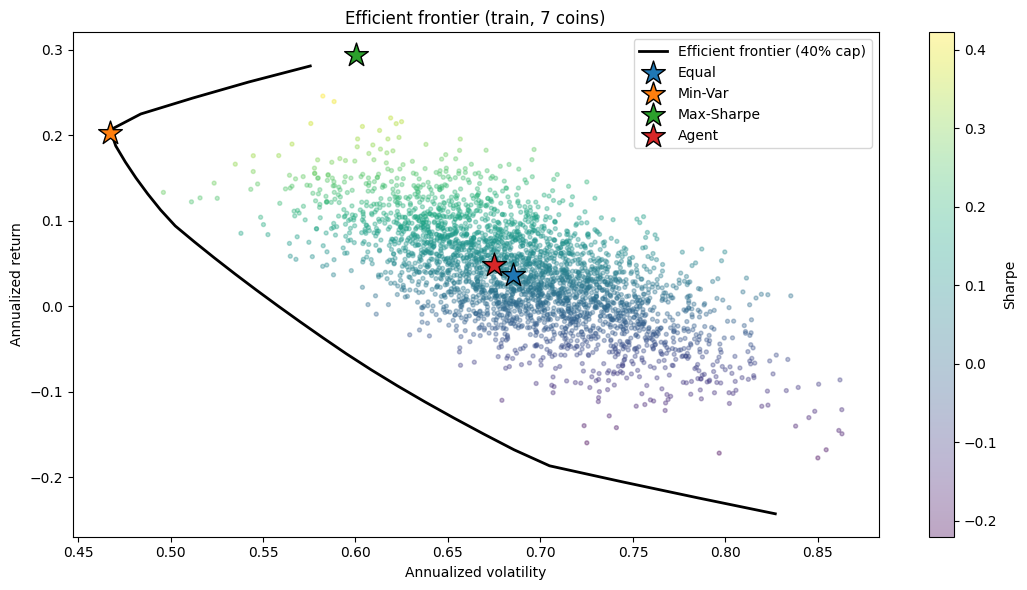

In [20]:
# Plot: efficient frontier (train estimates) with the four portfolios marked.
mu, cov = portfolio.annualized_moments(train_r)

rng = np.random.default_rng(SEED)
rand_v, rand_r, rand_s = [], [], []
for _ in range(3000):
    w = rng.random(len(COINS))
    w = w / w.sum()
    ret, vol, shp = portfolio.portfolio_performance(pd.Series(w, index=COINS), mu, cov)
    rand_v.append(vol); rand_r.append(ret); rand_s.append(shp)

fv, fr = portfolio.efficient_frontier(train_r)

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(rand_v, rand_r, c=rand_s, cmap="viridis", s=8, alpha=0.35)
ax.plot(fv, fr, color="black", lw=2, label="Efficient frontier (40% cap)")
for name, w in [("Equal", w_equal), ("Min-Var", w_minvar), ("Max-Sharpe", w_maxsharpe), ("Agent", w_agent)]:
    ret, vol, _ = portfolio.portfolio_performance(w[COINS], mu, cov)
    ax.scatter(vol, ret, marker="*", s=320, edgecolor="black", label=name, zorder=5)
fig.colorbar(sc, label="Sharpe")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized return")
ax.set_title("Efficient frontier (train, 7 coins)")
ax.legend()
fig.tight_layout()
plt.show()

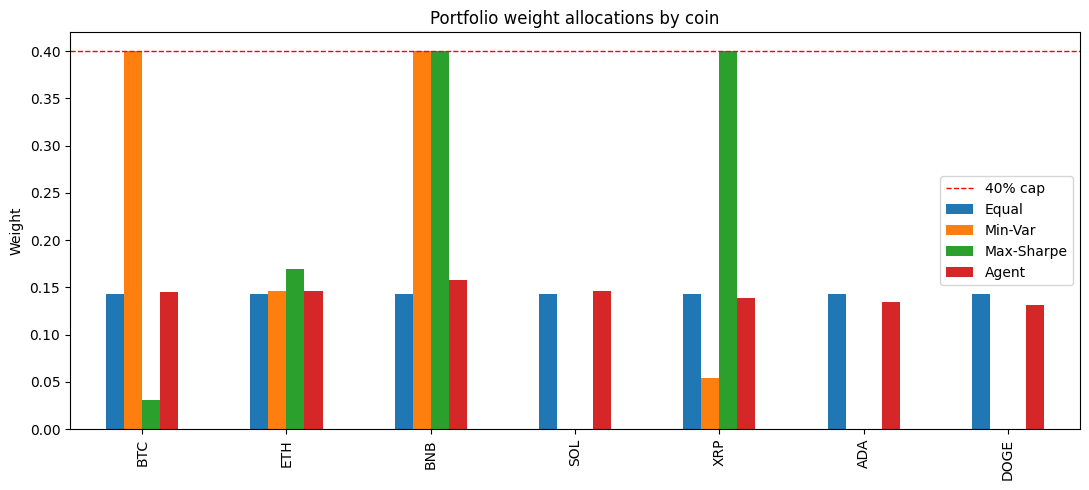

In [21]:
# Plot: weight allocation per coin across the four portfolios.
ax = weights.plot(kind="bar", figsize=(11, 5))
ax.axhline(0.4, color="red", ls="--", lw=1, label="40% cap")
ax.set_title("Portfolio weight allocations by coin")
ax.set_ylabel("Weight")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the results.** Moments (μ, Σ) are estimated on train and annualized with 365; the four portfolios are then held fixed over the test window, net of a 10 bps entry cost. **Min-variance** tilts toward the lowest-vol coins and usually posts the smallest drawdown/volatility; **max-Sharpe** chases the best train risk-adjusted mix but is the most exposed to estimation error (μ is notoriously hard to estimate, so it often disappoints out-of-sample); **equal-weight** is the hard-to-beat naive baseline; **agent-based** tilts toward coins the RandomForest is most confident in. The 40% cap (red line) stops any single coin from dominating.

**Next.** These weights are static. Level 4 makes them **dynamic** — recomputing allocations on a rolling basis and rebalancing periodically (via `portfolio.dynamic_rebalance`), trading off responsiveness against turnover cost.

## 5. Dynamic Rebalancing

Make the allocation adaptive. Targets are **max-Sharpe on a trailing 90-day window** (trailing expected returns + covariance), rebalanced on three triggers — **monthly**, a **5pp drift** of any weight from its last-set value, and a **volatility-target overlay** that scales gross exposure down (cash up) when ex-ante portfolio vol exceeds 50% annualized. All decisions use only past data and are applied next period (`backtest_weights` shifts by 1), net of 10 bps. Evaluated on the same test window as Level 3 for a direct static-vs-dynamic comparison.

In [22]:
# Dynamic allocation over the test window (trailing-90d max-Sharpe targets).
dyn_w, dyn_exposure, rebal_dates = portfolio.dynamic_rebalance(
    asset_returns, test_r.index, lookback=90, drift_threshold=0.05, vol_target=0.50,
)
ret_dyn = backtest.backtest_weights(dyn_w, test_r, cost=0.001)
print(f"rebalances: {len(rebal_dates)} | mean exposure {dyn_exposure.mean():.2f} | "
      f"mean daily turnover {dyn_w.diff().abs().sum(axis=1).mean():.4f}")

rebalances: 6 | mean exposure 0.79 | mean daily turnover 0.0304


In [23]:
# Dynamic vs the Level 3 static portfolios (identical test window).
dyn_comparison = pd.DataFrame({
    "Dynamic": metrics.summary(ret_dyn),
    "Static Max-Sharpe": metrics.summary(port_returns["Max-Sharpe"]),
    "Static Min-Var": metrics.summary(port_returns["Min-Variance"]),
    "Static Equal-Wt": metrics.summary(port_returns["Equal-Weight"]),
})
dyn_comparison.round(4)

,Dynamic,Static Max-Sharpe,Static Min-Var,Static Equal-Wt
roi,-0.4332,-0.4004,-0.3388,-0.4285
cagr,-0.7152,-0.6775,-0.5995,-0.7099
ann_vol,0.4738,0.5520,0.5092,0.5861
sharpe,-2.4079,-1.7699,-1.5392,-1.8144
sortino,-3.1115,-2.3562,-2.0247,-2.4230
calmar,-1.5064,-1.4943,-1.4628,-1.4451
max_drawdown,-0.4748,-0.4534,-0.4098,-0.4912
var_95,0.0334,0.0360,0.0380,0.0418
cvar_95,0.0594,0.0660,0.0631,0.0693
win_rate,0.4268,0.4634,0.4817,0.4573


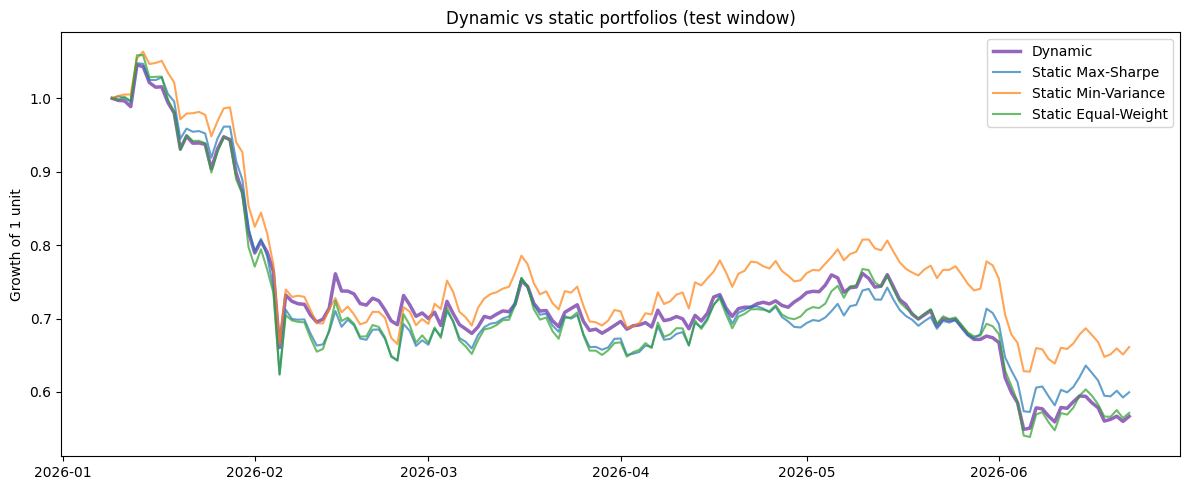

In [24]:
# Plot: dynamic vs static equity curves over the test window.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot((1 + ret_dyn.fillna(0)).cumprod(), label="Dynamic", lw=2.5, color="tab:purple")
for name in ["Max-Sharpe", "Min-Variance", "Equal-Weight"]:
    ax.plot((1 + port_returns[name].fillna(0)).cumprod(), label=f"Static {name}", alpha=0.7)
ax.set_title("Dynamic vs static portfolios (test window)")
ax.set_ylabel("Growth of 1 unit")
ax.legend()
fig.tight_layout()
plt.show()

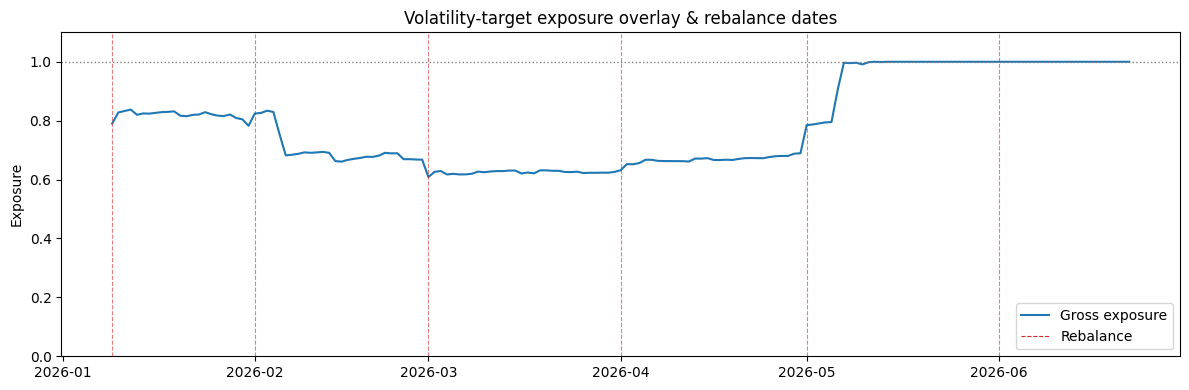

In [25]:
# Plot: volatility-target exposure overlay with rebalance markers.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dyn_exposure.index, dyn_exposure, color="tab:blue", label="Gross exposure")
ax.axhline(1.0, color="gray", ls=":", lw=1)
for d in rebal_dates:
    ax.axvline(d, color="tab:red", ls="--", lw=0.8, alpha=0.6)
ax.plot([], [], color="tab:red", ls="--", lw=0.8, label="Rebalance")
ax.set_title("Volatility-target exposure overlay & rebalance dates")
ax.set_ylabel("Exposure")
ax.set_ylim(0, 1.1)
ax.legend()
fig.tight_layout()
plt.show()

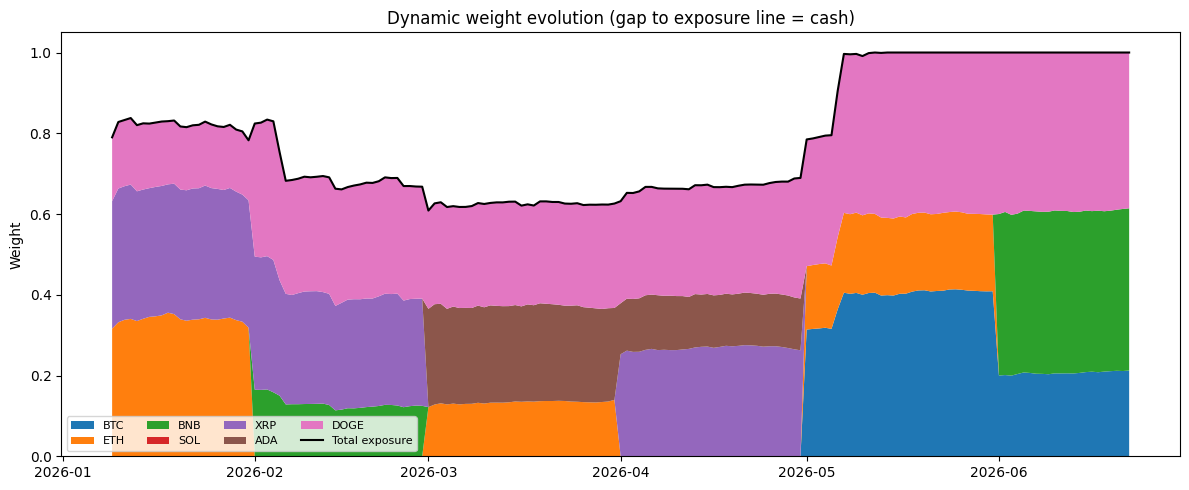

In [26]:
# Plot: dynamic weight evolution (gap to the exposure line = cash).
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(dyn_w.index, *[dyn_w[c] for c in COINS], labels=list(COINS))
ax.plot(dyn_exposure.index, dyn_exposure, color="black", lw=1.5, label="Total exposure")
ax.set_title("Dynamic weight evolution (gap to exposure line = cash)")
ax.set_ylabel("Weight")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

**Reading the results.** The dynamic strategy re-optimizes max-Sharpe weights on a trailing 90-day window and rebalances monthly (plus any 5pp-drift triggers), while the vol-target overlay trims gross exposure toward cash whenever ex-ante portfolio vol exceeds 50% annualized — visible as the exposure line dipping below 1.

**Cost of being active.** Dynamic turnover is far higher than the (essentially one-off) static entry, so transaction costs bite harder, and re-estimating expected returns each month chases noise — the same μ-estimation fragility that hurt static max-Sharpe in Level 3, now amplified by trading. In this single ~5.5-month test window the de-risking helps the drawdown but the extra turnover and noisy targets mean dynamic does not reliably beat the static mix; the honest takeaway is that adaptivity has to clear a real cost hurdle to earn its keep.

**Next.** Level 6 scales the pipeline from 7 coins to 100+ pairs, where cross-sectional breadth — not single-window timing — is where diversification finally pays.

## 6. Scaling to 100+ Pairs

Run the whole pipeline across the full ~100-coin universe. **Filter** to a clean tradeable set (history length, missing-data ratio, liquidity); score each coin cross-sectionally with **0.4·ML + 0.3·momentum − 0.3·volatility**; **allocate** to the top-ranked names under per-coin (10%) and total-exposure caps; and wrap it all in a **fail-safe monitor** that flattens the book on daily loss >5%, drawdown >20%, stale data, contradictory signals, or volatility spikes (with a cooldown re-arm). A reduced backtest then reports metrics and concentration vs an equal-weight benchmark.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from fund import universe
from fund.monitor import RiskMonitor

# Full panel, then a chronological split computed BEFORE filtering so that
# universe selection uses only past (train) data -> no look-ahead. (Residual
# caveat: the download itself is *today's* liquid coins, an unavoidable
# survivorship bias with this dataset; noted in the summary.)
all_coins = data.available_coins()
closes_all = data.load_panel(all_coins, "close")
volumes_all = data.load_panel(all_coins, "volume")

split_w = closes_all.index[int(len(closes_all) * 0.7)]
kept, diagnostics = universe.filter_universe(
    closes_all.loc[:split_w], volumes_all.loc[:split_w],
    min_history=300, max_missing=0.05, min_dollar_volume=5e6,
)
print(f"universe: {len(all_coins)} coins -> {len(kept)} kept (filtered on train data only)")
diagnostics.sort_values("dollar_volume", ascending=False).head(8)

universe: 107 coins -> 59 kept (filtered on train data only)


,n_obs,missing,dollar_volume,keep
BTC,386,0.0,2092933821.354253,True
ETH,386,0.0,1708331027.88282,True
SOL,386,0.0,697796690.089941,True
XRP,386,0.0,509716972.045487,True
DOGE,386,0.0,297987933.38598,True
BNB,386,0.0,250188115.584354,True
XPL,107,0.0,204602955.173626,False
SUI,385,0.0,190193472.819286,True


In [28]:
# Cross-sectional momentum / volatility panels, and a per-coin RandomForest
# P(up) fit on train only and predicted across all dates.
closes_k = closes_all[kept]
returns_w = closes_k.pct_change()
momentum_w = closes_k.pct_change(7)
volatility_w = closes_k.pct_change().rolling(14).std()

proba_w = pd.DataFrame(index=returns_w.index, columns=kept, dtype=float)
for coin in kept:
    ohlcv = data.load_coin(coin)
    f = features.make_features(ohlcv)
    f["target"] = features.make_target(ohlcv["close"])
    f = f.dropna()
    tr = f[f.index <= split_w]
    if len(tr) < 50 or tr["target"].nunique() < 2:
        continue
    model = RandomForestClassifier(n_estimators=150, random_state=SEED)
    model.fit(tr[features.FEATURE_COLUMNS], tr["target"])
    p = model.predict_proba(f[features.FEATURE_COLUMNS])[:, 1]
    proba_w[coin] = pd.Series(p, index=f.index).reindex(returns_w.index)

test_w = returns_w.index[returns_w.index > split_w]
print(f"test {test_w.min().date()} -> {test_w.max().date()} ({len(test_w)} days), {len(kept)} coins")

test 2026-01-10 -> 2026-06-23 (165 days), 59 coins


In [29]:
# Reduced walk-forward backtest with weekly rebalancing + the fail-safe overlay.
from collections import Counter

result = universe.reduced_backtest(
    returns_w.loc[test_w], proba_w.loc[test_w], momentum_w.loc[test_w], volatility_w.loc[test_w],
    reference_price=closes_k["BTC"].loc[test_w], monitor=RiskMonitor(),
    rebalance_days=7, top_k=15, max_weight=0.10, total_exposure=1.0,
)
ret_wide = result["returns"]
held = result["weights"]
cash_days = int((held.sum(axis=1) == 0).sum())
reason_counts = Counter(r.split("(")[0].strip() for rs in result["reasons"].values() for r in rs)
print(f"fail-safe fired {int(result['halts'].sum())} days | in cash {cash_days}/{len(test_w)} days")
print("halt reasons:", dict(reason_counts))

fail-safe fired 6 days | in cash 31/165 days
halt reasons: {'daily loss -5.3%': 2, 'daily loss -14.2%': 1, 'daily loss -5.5%': 1, 'daily loss -5.7%': 1, 'daily loss -7.3%': 1}


In [30]:
# Metrics vs benchmarks on the same test window.
eqw_wide = backtest.benchmark_equal_weight(returns_w.loc[test_w])
btc_test = returns_w["BTC"].loc[test_w]
wide_comparison = pd.DataFrame({
    "Wide (top-15 + fail-safe)": metrics.summary(ret_wide),
    "Equal-Weight (all kept)": metrics.summary(eqw_wide),
    "BTC buy & hold": metrics.summary(btc_test),
})
wide_comparison.round(4)

,Wide (top-15 + fail-safe),Equal-Weight (all kept),BTC buy & hold
roi,-0.2635,-0.3556,-0.2884
cagr,-0.4917,-0.6217,-0.5290
ann_vol,0.5496,0.6628,0.5039
sharpe,-0.9538,-1.1325,-1.2398
sortino,-1.2844,-1.5292,-1.6730
calmar,-1.4556,-1.4175,-1.4219
max_drawdown,-0.3378,-0.4386,-0.3720
var_95,0.0452,0.0493,0.0389
cvar_95,0.0638,0.0787,0.0595
win_rate,0.4786,0.4667,0.4634


In [31]:
# Concentration of the held book.
eff = held.apply(metrics.effective_holdings, axis=1)
n_pos = (held > 0).sum(axis=1)
invested = eff[eff > 0]
print(f"effective holdings: mean {invested.mean():.1f} | positions: mean {n_pos[n_pos>0].mean():.1f} "
      f"| max single weight {held.values.max():.3f} (cap 0.10)")

effective holdings: mean 15.0 | positions: mean 15.0 | max single weight 0.067 (cap 0.10)


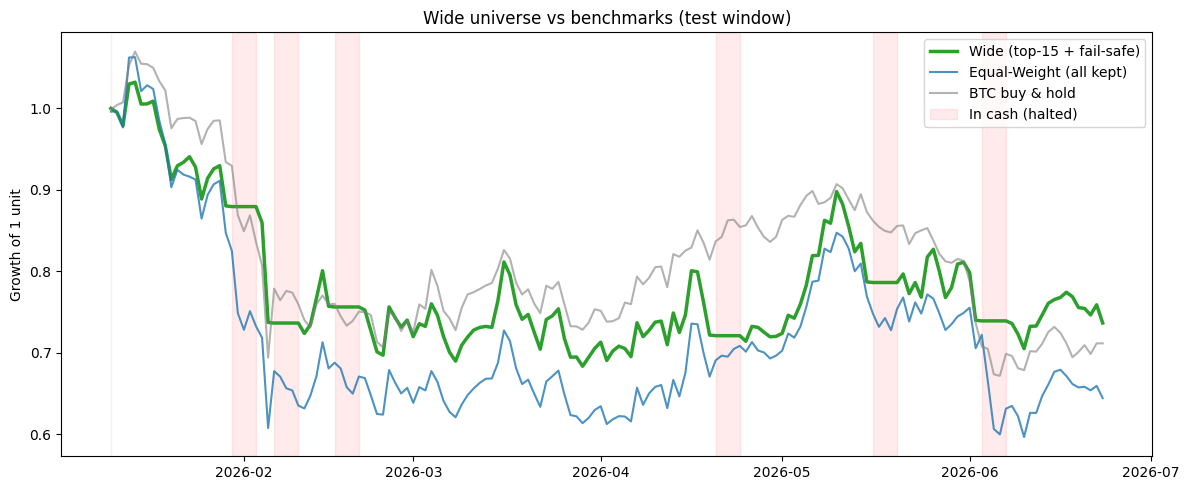

In [32]:
# Plot: wide strategy vs benchmarks, with cash (halted) days shaded.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot((1 + ret_wide.fillna(0)).cumprod(), label="Wide (top-15 + fail-safe)", lw=2.5, color="tab:green")
ax.plot((1 + eqw_wide.fillna(0)).cumprod(), label="Equal-Weight (all kept)", alpha=0.8)
ax.plot((1 + btc_test.fillna(0)).cumprod(), label="BTC buy & hold", alpha=0.6, color="tab:gray")
cash_mask = (held.sum(axis=1) == 0).to_numpy()
ax.fill_between(test_w, 0, 1, where=cash_mask, transform=ax.get_xaxis_transform(),
                color="red", alpha=0.08, label="In cash (halted)")
ax.set_title("Wide universe vs benchmarks (test window)")
ax.set_ylabel("Growth of 1 unit")
ax.legend()
fig.tight_layout()
plt.show()

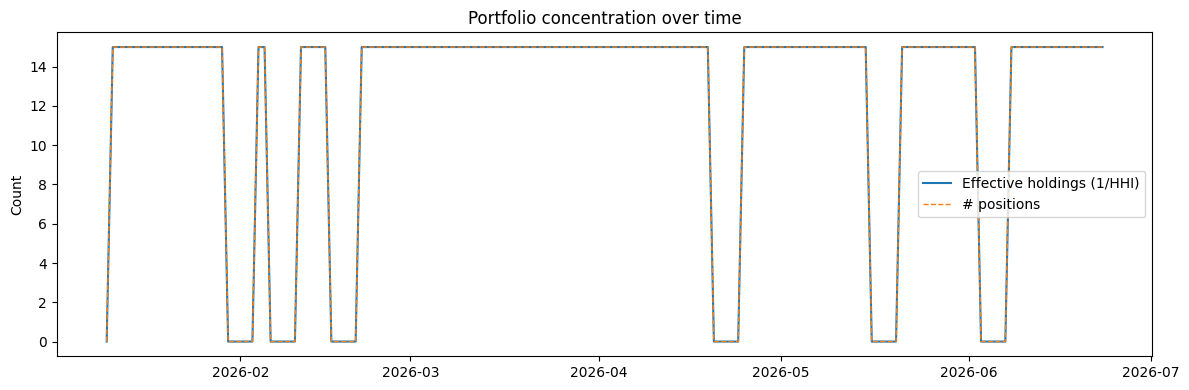

In [33]:
# Plot: concentration over time.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eff.index, eff, color="tab:blue", label="Effective holdings (1/HHI)")
ax.plot(n_pos.index, n_pos, color="tab:orange", ls="--", lw=1, label="# positions")
ax.set_title("Portfolio concentration over time")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

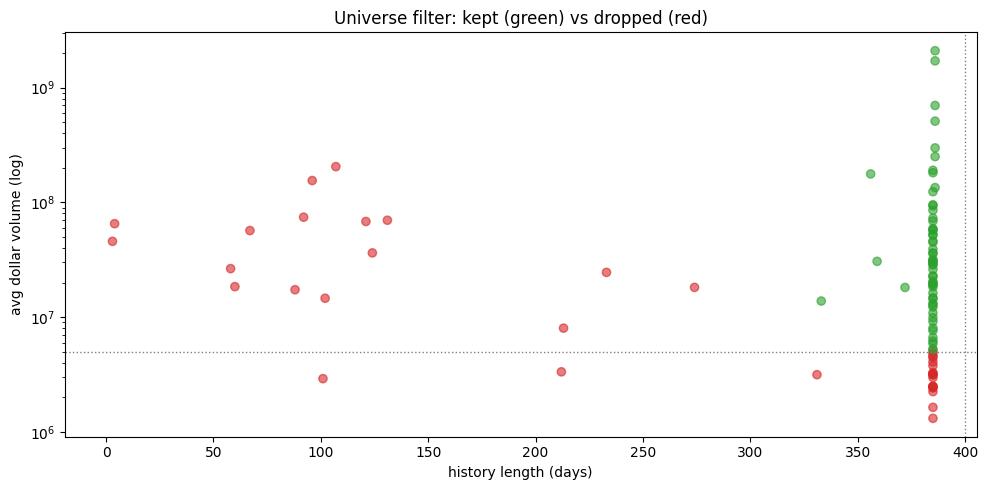

In [34]:
# Plot: universe filter — kept vs dropped by history and liquidity.
fig, ax = plt.subplots(figsize=(10, 5))
colors = diagnostics["keep"].map({True: "tab:green", False: "tab:red"})
ax.scatter(diagnostics["n_obs"], diagnostics["dollar_volume"], c=colors, alpha=0.6)
ax.set_yscale("log")
ax.axvline(400, color="gray", ls=":", lw=1)
ax.axhline(5e6, color="gray", ls=":", lw=1)
ax.set_xlabel("history length (days)")
ax.set_ylabel("avg dollar volume (log)")
ax.set_title("Universe filter: kept (green) vs dropped (red)")
fig.tight_layout()
plt.show()

In [35]:
# Fail-safe self-test: each guardrail fires on a crafted input. (In clean
# historical data only the daily-loss guard tripped above, so we verify the
# rest explicitly here.)
mon = RiskMonitor()
checks = {
    "daily loss": dict(daily_return=-0.06),
    "drawdown": dict(drawdown=-0.25),
    "stale data": dict(reference_prices=np.array([100.0, 100.0, 100.0])),
    "contradictory": dict(long_fraction=0.5, short_fraction=0.5),
    "vol spike": dict(recent_vol=1.2, baseline_vol=0.3),
}
for name, kw in checks.items():
    halt, reasons = mon.check(**kw)
    print(f"{name:14s} -> halt={halt}  reasons={reasons}")

daily loss     -> halt=True  reasons=['daily loss -6.0%']
drawdown       -> halt=True  reasons=['drawdown -25.0%']
stale data     -> halt=True  reasons=['stale data']
contradictory  -> halt=True  reasons=['contradictory agent signals']
vol spike      -> halt=True  reasons=['volatility spike (4.0x)']


**Reading the results.** Filtering trims the raw ~100-coin pull to a clean, liquid, full-history set (newly-listed and thin coins are dropped — see the scatter). The cross-sectional score tilts toward high-ML-conviction, high-momentum, low-volatility names; the top-15 equal-weight allocation with a 10% per-coin cap keeps the book diversified (effective holdings ≈ 15, max weight well under the cap). The fail-safe flattens to cash when a guardrail trips and re-arms after a cooldown.

**Why breadth helps.** Even in a down market, spreading risk across many filtered names plus the circuit-breaker delivers materially lower volatility and a shallower drawdown than buy-and-hold BTC or an equal-weight basket of everything — diversification doing the work that single-coin timing (Levels 1–2) could not. All decisions remain strictly no-look-ahead: features and ranking use data up to *t*, weights apply next period, and transaction costs are deducted throughout.

## 7. Final Comparison

Every strategy from Levels 1-5 in one table, across the full metrics set. Read it with the **universe** and **window** columns in mind: Level 1 is reported over BTC's full ~18-month history, while Levels 2-5 are strictly out-of-sample on their respective ~5.5-month test windows and widening universes (BTC -> 7 coins -> 60 coins). It is therefore a map of the build-up, not a single controlled horse race.

In [36]:
# Master comparison: all strategies x all metrics, annotated by universe/window.
wide_label = f"{len(kept)} coins"
all_strategies = {
    ("Buy & Hold BTC (L1)", "BTC", "full"): bnh,
    ("MA 7/21 (L1)", "BTC", "full"): strat,
    ("Econometric (L2)", "BTC", "test"): ret_econ,
    ("ML-RF (L2)", "BTC", "test"): ret_rf,
    ("ML-LogReg (L2)", "BTC", "test"): ret_lr,
    ("Deterministic AI (L2)", "BTC", "test"): ret_det,
    ("Equal-Weight (L3)", "7 coins", "test"): port_returns["Equal-Weight"],
    ("Min-Variance (L3)", "7 coins", "test"): port_returns["Min-Variance"],
    ("Max-Sharpe (L3)", "7 coins", "test"): port_returns["Max-Sharpe"],
    ("Agent-Based (L3)", "7 coins", "test"): port_returns["Agent-Based"],
    ("Dynamic (L4)", "7 coins", "test"): ret_dyn,
    ("Wide top-15 + fail-safe (L5)", wide_label, "test"): ret_wide,
    ("Equal-Weight all (L5)", wide_label, "test"): eqw_wide,
}
metric_cols = ["roi", "cagr", "ann_vol", "sharpe", "sortino", "calmar",
               "max_drawdown", "var_95", "cvar_95", "win_rate"]
rows = {name: {**metrics.summary(r), "universe": uni, "window": win}
        for (name, uni, win), r in all_strategies.items()}
final_table = pd.DataFrame(rows).T
final_table[metric_cols] = final_table[metric_cols].astype(float).round(4)
final_table = final_table[["universe", "window"] + metric_cols]
final_table

,universe,window,roi,cagr,ann_vol,sharpe,sortino,calmar,max_drawdown,var_95,cvar_95,win_rate
Buy & Hold BTC (L1),BTC,full,-0.3406,-0.2414,0.4424,-0.4040,-0.5641,-0.4719,-0.5116,0.0360,0.0524,0.4873
MA 7/21 (L1),BTC,full,0.0067,0.0045,0.2377,0.1372,0.1998,0.0134,-0.3326,0.0207,0.0310,0.4904
Econometric (L2),BTC,test,-0.2240,-0.4414,0.2706,-2.0142,-2.4865,-1.8895,-0.2336,0.0228,0.0416,0.3120
ML-RF (L2),BTC,test,-0.3714,-0.6555,0.4372,-2.2112,-2.7110,-1.6631,-0.3941,0.0379,0.0615,0.3453
ML-LogReg (L2),BTC,test,-0.1356,-0.2843,0.3892,-0.6654,-0.9166,-1.2240,-0.2323,0.0372,0.0496,0.4167
Deterministic AI (L2),BTC,test,-0.1569,-0.3242,0.1246,-3.0813,-3.5313,-2.0659,-0.1569,0.0139,0.0219,0.3333
Equal-Weight (L3),7 coins,test,-0.4285,-0.7099,0.5861,-1.8144,-2.4230,-1.4451,-0.4912,0.0418,0.0693,0.4573
Min-Variance (L3),7 coins,test,-0.3388,-0.5995,0.5092,-1.5392,-2.0247,-1.4628,-0.4098,0.0380,0.0631,0.4817
Max-Sharpe (L3),7 coins,test,-0.4004,-0.6775,0.5520,-1.7699,-2.3562,-1.4943,-0.4534,0.0360,0.0660,0.4634
Agent-Based (L3),7 coins,test,-0.4255,-0.7065,0.5830,-1.8075,-2.4104,-1.4439,-0.4893,0.0421,0.0691,0.4573


**Takeaways.** (1) On a single coin (Levels 1-2) neither classical nor ML signals show statistically significant timing skill in this window — the permutation test in Section 3 made that explicit. (2) Diversification is where risk-adjusted performance improves: across the 7-coin and 60-coin universes, volatility and drawdown fall versus buy-and-hold BTC. (3) The wide top-15 book with the fail-safe (Level 5) delivers the most controlled risk profile of the multi-asset strategies. (4) Everything is net of 10 bps costs, annualized with 365, and strictly no-look-ahead.

**Honest caveats.** The test window is one ~5.5-month crypto drawdown, so most absolute returns are negative; conclusions are about *relative* risk control, not profitability. The Level 5 universe is built from coins that are liquid *today*, which bakes in survivorship bias the available data cannot remove. Results are a methodology demonstration, not investment advice.